# Exploring the Role of the Complement Cascade in CKD and AKI
> Side-mission is to create a Complement Cascade Atlas in the Human Kidney

## Download data from CZ CELLxGENE

Download data from CZ CELLxGENE using [TODO] and aquire citation for data.

In [ ]:
!mkdir /Users/aumchampaneri/VSCode/hs-ckd-aki/data/

In [ ]:
import cellxgene_census
census = cellxgene_census.open_soma(census_version="latest")
census["census_info"]["summary"].read().concat().to_pandas()
datasets = census["census_info"]["datasets"].read().concat().to_pandas()

In [ ]:
dataset_id = "7ff0197b-d175-49bf-b4fa-150fe0995d93"
datasets[datasets["dataset_id"] == dataset_id].iloc[0]

In [ ]:
# BROKEN - MANUALLY DOWNLOADED FROM CELLXGENE CENSUS UI
cellxgene_census.download_source_h5ad(
    "f337b525-c8f7-4c96-8cfe-f258a9f5ca48", 
    to_path="/Users/aumchampaneri/VSCode/hs-ckd-aki/data/f337b525-c8f7-4c96-8cfe-f258a9f5ca48.h5ad", 
    census_version="latest",
    progress_bar=True
)
census.close()

## scVI Processing



In [ ]:
import scanpy as sc
import scvi
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch

In [ ]:
!mkdir /Users/aumchampaneri/VSCode/hs-ckd-aki/outputs/scVI-process

In [ ]:
adata = sc.read_h5ad("/Users/aumchampaneri/VSCode/hs-ckd-aki/data/f337b525-c8f7-4c96-8cfe-f258a9f5ca48.h5ad")
adata

### Inspection

In [ ]:
adata.obs[
    [
        "nFeature_RNA",
        "nCount_RNA",
        "percent.mt"
    ]
].describe()

In [ ]:
adata.raw
adata.raw.X

In [ ]:
adata.raw.X.shape
adata.raw.X[:5, :5]

In [ ]:
adata.X = adata.raw.X.copy()


### HVG: Selction-Subset-Store

In [ ]:
scvi.data.poisson_gene_selection(adata)

In [ ]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [ ]:
adata.layers["counts"] = adata.X.copy()

if not sp.issparse(adata.layers["counts"]):
    adata.layers["counts"] = sp.csr_matrix(adata.layers["counts"])

In [ ]:
adata.obs["batch"] = (
    adata.obs["donor_id"].astype(str)
    + "_"
    + adata.obs["library"].astype(str)
)

adata.obs["batch"] = adata.obs["batch"].astype("category")

### scVI: Setup-Initialize-Train

In [ ]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="batch"
)

In [ ]:
model = scvi.model.SCVI(
    adata,
    n_layers=2,
    n_hidden=256,
    n_latent=30,
    dropout_rate=0.1,
    gene_likelihood="nb" # We use Negative Binomial count likelihoods, following Boyeau et al., 2023.
)

model.train(
    max_epochs=300,
    batch_size=2048,
    early_stopping=True,
    early_stopping_patience=20,
    early_stopping_monitor="elbo_validation",
    accelerator="mps",
    plan_kwargs={"lr": 1e-3},
)

In [ ]:
import matplotlib.pyplot as plt

# Ensure convergence
train_test_results = model.history["elbo_train"]
train_test_results["elbo_validation"] = model.history["elbo_validation"]
train_test_results.iloc[10:].plot(logy=True)  # exclude first 10 epochs
plt.show()

### Extraction and Embedding

In [ ]:
adata.obsm["X_scVI"] = model.get_latent_representation()

In [ ]:
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)
sc.tl.umap(adata, min_dist=0.3)

## Trajectory and Manifold Analysis


In [5]:
import re
from pathlib import Path

import scanpy as sc
import scvi
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import spearmanr
import torch
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
output_dir = Path("/Users/aumchampaneri/VSCode/hs-ckd-aki/outputs/scVI-tm")
output_dir.mkdir(parents=True, exist_ok=True)

annotation_layers = [
    "Class",
    "SubclassLevel1",
    "SubclassLevel2",
    "SubclassLevel3",
    "SubclassLevel3_FullName",
    "cell_type",
    "CellStateLevel1",
    "CellStateLevel2",
]

egfr_col = "Baseline eGFR (ml/min/1.73m2) (Binned)"
min_cells = 500
min_donors = 5


In [7]:
adata = sc.read_h5ad("/Users/aumchampaneri/VSCode/hs-ckd-aki/input-data/kidney_scvi_atlas_rawcounts.h5ad")
adata


AnnData object with n_obs × n_vars = 1388643 × 4000
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'experiment_id', 'suspension_type', 'assay_ontology_term_id', 'donor_id', 'specimen', 'Conditions.Subtype', 'disease_ontology_term_id', 'diabetes_history', 'hypertension', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'region', 'percent.cortex', 'percent.medulla', 'tissue_type', 'tissue_ontology_term_id', 'Clusters', 'SubclassLevel3', 'SubclassLevel2', 'SubclassLevel1', 'CellStateLevel2', 'CellStateLevel1', 'Class', 'cell_type_ontology_term_id', 'ConditionCategory', 'TissueCollection', 'Race', 'AdjudicationCategory', 'Baseline eGFR (ml/min/1.73m2) (Binned)', 'SubclassLevel3_FullName', 'Age', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch', '_scvi_batch', '_scvi_labels'
    var: 'feature_is_filtered', '

#### Setup and Validation


In [8]:
required_obsm = ["X_scVI", "X_umap"]
required_obsp = ["connectivities", "distances"]
required_obs = ["donor_id", "disease", egfr_col] + annotation_layers

missing = []
if adata.raw is None:
    missing.append("adata.raw")
missing.extend([f"adata.obsm['{key}']" for key in required_obsm if key not in adata.obsm])
missing.extend([f"adata.obsp['{key}']" for key in required_obsp if key not in adata.obsp])
missing.extend([f"adata.obs['{key}']" for key in required_obs if key not in adata.obs])

if missing:
    raise ValueError("Missing required AnnData fields: " + ", ".join(missing))

print(f"Cells: {adata.n_obs:,}")
print(f"HVG genes in adata.X: {adata.n_vars:,}")
print(f"Raw genes for scoring: {adata.raw.n_vars:,}")
print(f"Output directory: {output_dir}")
print("Annotation layers:")
for layer in annotation_layers:
    print(f"  {layer}: {adata.obs[layer].nunique(dropna=True):,} groups")


Cells: 1,388,643
HVG genes in adata.X: 4,000
Raw genes for scoring: 35,455
Output directory: /Users/aumchampaneri/VSCode/hs-ckd-aki/outputs/scVI-tm
Annotation layers:
  Class: 5 groups
  SubclassLevel1: 18 groups
  SubclassLevel2: 89 groups
  SubclassLevel3: 128 groups
  SubclassLevel3_FullName: 128 groups
  cell_type: 63 groups
  CellStateLevel1: 2 groups
  CellStateLevel2: 8 groups


#### eGFR Severity Encoding


In [9]:
def parse_egfr_bin(value):
    if pd.isna(value):
        return {"egfr_midpoint": np.nan, "kidney_severity": np.nan}

    text = str(value).strip()
    if text == "Not available":
        return {"egfr_midpoint": np.nan, "kidney_severity": np.nan}
    if text.startswith(">60"):
        midpoint = 65.0
    else:
        match = re.match(r"^(\d+)-(\d+)\s+ml/min/1\.73m2$", text)
        if match is None:
            return {"egfr_midpoint": np.nan, "kidney_severity": np.nan}
        low, high = map(float, match.groups())
        midpoint = (low + high) / 2

    # Higher kidney_severity means worse kidney function.
    severity = max(0.0, (130.0 - midpoint) / 10.0)
    return {"egfr_midpoint": midpoint, "kidney_severity": severity}

unique_egfr_bins = pd.Series(adata.obs[egfr_col].drop_duplicates().astype(object))
egfr_lookup = {value: parse_egfr_bin(value) for value in unique_egfr_bins}
midpoint_lookup = {value: parsed["egfr_midpoint"] for value, parsed in egfr_lookup.items()}
severity_lookup = {value: parsed["kidney_severity"] for value, parsed in egfr_lookup.items()}

adata.obs["egfr_midpoint"] = adata.obs[egfr_col].map(midpoint_lookup).astype(float)
adata.obs["kidney_severity"] = adata.obs[egfr_col].map(severity_lookup).astype(float)

egfr_mapping = (
    adata.obs[[egfr_col, "egfr_midpoint", "kidney_severity"]]
    .drop_duplicates()
    .sort_values(["egfr_midpoint", egfr_col], na_position="last")
)
print(egfr_mapping.to_string(index=False))

conflicting_donor_egfr = (
    adata.obs[["donor_id", egfr_col]]
    .drop_duplicates()
    .groupby("donor_id", observed=True)[egfr_col]
    .nunique(dropna=False)
)
print(f"Donors with multiple eGFR bins: {(conflicting_donor_egfr > 1).sum()}")


Baseline eGFR (ml/min/1.73m2) (Binned)  egfr_midpoint  kidney_severity
                     0-9 ml/min/1.73m2            4.5            12.55
                   20-29 ml/min/1.73m2           24.5            10.55
                   30-39 ml/min/1.73m2           34.5             9.55
                   40-49 ml/min/1.73m2           44.5             8.55
                   50-59 ml/min/1.73m2           54.5             7.55
                   60-69 ml/min/1.73m2           64.5             6.55
                     >60 ml/min/1.73m2           65.0             6.50
                   70-79 ml/min/1.73m2           74.5             5.55
                   80-89 ml/min/1.73m2           84.5             4.55
                   90-99 ml/min/1.73m2           94.5             3.55
                 100-109 ml/min/1.73m2          104.5             2.55
                 110-119 ml/min/1.73m2          114.5             1.55
                 120-129 ml/min/1.73m2          124.5             0.55
      

#### Complement Scoring From Raw Counts


In [10]:
complement_gene_sets = {
    "classical": [
        "C1QA", "C1QB", "C1QC", "C1R", "C1S", "C2", "C4A", "C4B", "C4BPA", "C4BPB"
    ],
    "lectin": [
        "MBL2", "FCN1", "FCN2", "FCN3", "MASP1", "MASP2", "MASP3"
    ],
    "alternative": [
        "C3", "CFB", "CFD", "CFP", "C3AR1"
    ],
    "terminal": [
        "C5", "C5AR1", "C5AR2", "C6", "C7", "C8A", "C8B", "C8G", "C9"
    ],
    "receptor": [
        "C3AR1", "C5AR1", "C5AR2", "CR1", "CR2", "ITGAM", "ITGAX", "VSIG4"
    ],
    "regulator": [
        "CFH", "CFHR1", "CFHR2", "CFHR3", "CFHR4", "CFHR5", "CFI", "CD46", "CD55", "CD59", "SERPING1"
    ],
}


In [11]:
def build_raw_gene_symbol_map(adata):
    raw_var = adata.raw.var
    if "feature_name" in raw_var.columns:
        return dict(zip(raw_var["feature_name"].astype(str), raw_var.index.astype(str)))
    return dict(zip(raw_var.index.astype(str), raw_var.index.astype(str)))


def score_gene_program_from_raw(adata, gene_symbols, score_name, min_genes=2):
    gene_map = build_raw_gene_symbol_map(adata)
    genes_resolved = [gene_map[g] for g in gene_symbols if g in gene_map]
    missing = [g for g in gene_symbols if g not in gene_map]

    print(f"{score_name}: {len(genes_resolved)}/{len(gene_symbols)} genes resolved")
    if missing:
        print(f"  missing: {missing}")
    if len(genes_resolved) < min_genes:
        raise ValueError(f"{score_name} has too few resolved genes: {genes_resolved}")

    sc.tl.score_genes(
        adata,
        gene_list=genes_resolved,
        use_raw=True,
        score_name=score_name,
    )
    return genes_resolved, missing

resolved_complement_genes = {}
missing_complement_genes = {}
for program, genes in complement_gene_sets.items():
    resolved, missing = score_gene_program_from_raw(
        adata,
        genes,
        f"{program}_score",
    )
    resolved_complement_genes[program] = resolved
    missing_complement_genes[program] = missing


classical_score: 10/10 genes resolved
lectin_score: 6/7 genes resolved
  missing: ['MASP3']
alternative_score: 5/5 genes resolved
terminal_score: 9/9 genes resolved
receptor_score: 8/8 genes resolved
regulator_score: 11/11 genes resolved


#### Derived Complement Metrics


In [12]:
program_score_cols = [f"{program}_score" for program in complement_gene_sets]
producer_score_cols = [
    "classical_score",
    "lectin_score",
    "alternative_score",
    "terminal_score",
    "regulator_score",
]
activation_score_cols = [
    "classical_score",
    "lectin_score",
    "alternative_score",
    "terminal_score",
    "receptor_score",
]

adata.obs["production_score"] = adata.obs[producer_score_cols].mean(axis=1)
adata.obs["response_score"] = adata.obs["receptor_score"]
adata.obs["activation_index"] = adata.obs[activation_score_cols].mean(axis=1) - adata.obs["regulator_score"]
adata.obs["net_complement_load"] = adata.obs[program_score_cols].sum(axis=1)
adata.obs["dominant_pathway"] = (
    adata.obs[program_score_cols]
    .idxmax(axis=1)
    .str.replace("_score", "", regex=False)
    .astype("category")
)

adata.obs[
    program_score_cols + [
        "production_score",
        "response_score",
        "activation_index",
        "net_complement_load",
        "dominant_pathway",
    ]
].head()


,classical_score,lectin_score,alternative_score,terminal_score,receptor_score,regulator_score,production_score,response_score,activation_index,net_complement_load,dominant_pathway
KC33_AAACCCACAACTGAAA-1,-0.0150,0.000,-0.024,0.060000,-0.020,-0.095768,-0.014954,-0.020,0.095968,-0.094768,terminal
KC33_AAACGAACAACGATCT-1,-0.0725,-0.020,-0.028,-0.168889,0.090,-0.143349,-0.086548,0.090,0.103471,-0.342738,receptor
KC33_AAACGAACACCGTGGT-1,-0.0175,0.000,-0.012,-0.028889,-0.005,-0.026726,-0.017023,-0.005,0.014048,-0.090115,lectin
KC33_AAACGCTAGCTAGTTC-1,-0.0125,-0.008,-0.004,-0.024444,-0.020,0.083823,0.006976,-0.020,-0.097612,0.014878,regulator
KC33_AAACGCTCATAACTCG-1,-0.0150,-0.012,-0.016,-0.024444,-0.030,0.021867,-0.009116,-0.030,-0.041356,-0.075578,regulator


#### Donor-Aware Complement Ranking


In [13]:
ranking_score_cols = program_score_cols + [
    "production_score",
    "response_score",
    "activation_index",
    "net_complement_load",
]


def zscore(series):
    series = pd.to_numeric(series, errors="coerce")
    std = series.std(skipna=True)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=series.index)
    return (series - series.mean(skipna=True)) / std


def safe_spearman(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if valid.shape[0] < min_donors or valid["y"].nunique() < 2 or valid["x"].nunique() < 2:
        return pd.Series({"severity_rho": np.nan, "severity_pval": np.nan})
    rho, pval = spearmanr(valid["x"], valid["y"])
    return pd.Series({"severity_rho": rho, "severity_pval": pval})


def build_layer_ranking(adata, layer):
    obs_cols = [
        layer,
        "donor_id",
        "disease",
        "kidney_severity",
        "egfr_midpoint",
    ] + ranking_score_cols
    obs = adata.obs[obs_cols].copy()
    obs = obs.rename(columns={layer: "population"})
    obs["population"] = obs["population"].astype(str)

    donor_summary = (
        obs.groupby(["population", "donor_id"], observed=True)
        .agg(
            n_cells=("donor_id", "size"),
            disease=("disease", lambda x: x.dropna().astype(str).mode().iat[0] if not x.dropna().empty else np.nan),
            kidney_severity=("kidney_severity", "first"),
            egfr_midpoint=("egfr_midpoint", "first"),
            **{col: (col, "mean") for col in ranking_score_cols},
        )
        .reset_index()
    )

    total_cells = len(obs)
    population_summary = (
        donor_summary.groupby("population", observed=True)
        .agg(
            n_cells=("n_cells", "sum"),
            n_donors=("donor_id", "nunique"),
            mean_cells_per_donor=("n_cells", "mean"),
            severity_bins_observed=("kidney_severity", lambda x: x.dropna().nunique()),
            egfr_midpoint_mean=("egfr_midpoint", "mean"),
            kidney_severity_mean=("kidney_severity", "mean"),
            **{f"{col}_mean": (col, "mean") for col in ranking_score_cols},
            **{f"{col}_sd": (col, "std") for col in ranking_score_cols},
        )
        .reset_index()
    )
    population_summary["cell_fraction"] = population_summary["n_cells"] / total_cells

    severity_stats = (
        donor_summary.groupby("population", observed=True)
        .apply(lambda df: safe_spearman(df["activation_index"], df["kidney_severity"]), include_groups=False)
        .reset_index()
    )
    population_summary = population_summary.merge(severity_stats, on="population", how="left")

    pathway_mean_cols = [f"{col}_mean" for col in program_score_cols]
    dominant_pathway = (
        population_summary[pathway_mean_cols]
        .idxmax(axis=1)
        .str.replace("_score_mean", "", regex=False)
    )
    population_summary["dominant_pathway"] = dominant_pathway

    disease_mean = (
        donor_summary.groupby(["population", "disease"], observed=True)["activation_index"]
        .mean()
        .unstack()
    )
    for disease_label in ["normal", "chronic kidney disease", "acute kidney failure"]:
        if disease_label not in disease_mean.columns:
            disease_mean[disease_label] = np.nan
    disease_mean["ckd_vs_normal_delta"] = disease_mean["chronic kidney disease"] - disease_mean["normal"]
    disease_mean["aki_vs_normal_delta"] = disease_mean["acute kidney failure"] - disease_mean["normal"]
    disease_mean["disease_dynamic_range"] = disease_mean[
        ["normal", "chronic kidney disease", "acute kidney failure"]
    ].max(axis=1) - disease_mean[["normal", "chronic kidney disease", "acute kidney failure"]].min(axis=1)
    disease_mean = disease_mean[
        ["ckd_vs_normal_delta", "aki_vs_normal_delta", "disease_dynamic_range"]
    ].reset_index()
    population_summary = population_summary.merge(disease_mean, on="population", how="left")

    population_summary["passes_min_cells"] = population_summary["n_cells"] >= min_cells
    population_summary["passes_min_donors"] = population_summary["n_donors"] >= min_donors
    population_summary["passes_severity_range"] = population_summary["severity_bins_observed"] >= 2
    population_summary["passes_candidate_filters"] = (
        population_summary["passes_min_cells"]
        & population_summary["passes_min_donors"]
        & population_summary["passes_severity_range"]
    )

    population_summary["annotation_layer"] = layer
    population_summary["abs_severity_rho"] = population_summary["severity_rho"].abs()
    population_summary["severity_association_direction"] = np.select(
        [
            population_summary["severity_rho"] > 0,
            population_summary["severity_rho"] < 0,
        ],
        ["positive", "negative"],
        default="none_or_unknown",
    )
    population_summary["activation_direction"] = np.select(
        [
            population_summary["activation_index_mean"] > 0,
            population_summary["activation_index_mean"] < 0,
        ],
        ["high_activation", "low_activation"],
        default="neutral",
    )
    population_summary["severity_association_type"] = np.select(
        [
            (population_summary["severity_rho"] > 0) & (population_summary["activation_index_mean"] > 0),
            population_summary["severity_rho"] > 0,
            population_summary["severity_rho"] < 0,
        ],
        ["hyperactivation", "positive_dysregulation", "suppression"],
        default="none_or_unknown",
    )

    priority_components = pd.DataFrame(
        {
            "activation_magnitude": zscore(population_summary["activation_index_mean"].abs()),
            "severity_association": zscore(population_summary["abs_severity_rho"]),
            "disease_dynamic_range": zscore(population_summary["disease_dynamic_range"]),
            "donor_support": zscore(np.log1p(population_summary["n_donors"])),
            "cell_support": zscore(np.log1p(population_summary["n_cells"])),
        },
        index=population_summary.index,
    ).fillna(0.0)
    population_summary["dysregulation_priority_score"] = priority_components.sum(axis=1)
    # Backward-compatible alias used by earlier notebook cells and exports.
    population_summary["trajectory_priority_score"] = population_summary["dysregulation_priority_score"]

    ordered_cols = [
        "annotation_layer",
        "population",
        "n_cells",
        "n_donors",
        "cell_fraction",
        "mean_cells_per_donor",
        "severity_bins_observed",
        "egfr_midpoint_mean",
        "kidney_severity_mean",
        "dominant_pathway",
        "activation_direction",
        "severity_rho",
        "abs_severity_rho",
        "severity_pval",
        "severity_association_direction",
        "severity_association_type",
        "ckd_vs_normal_delta",
        "aki_vs_normal_delta",
        "disease_dynamic_range",
        "passes_min_cells",
        "passes_min_donors",
        "passes_severity_range",
        "passes_candidate_filters",
        "dysregulation_priority_score",
        "trajectory_priority_score",
    ]
    remaining_cols = [col for col in population_summary.columns if col not in ordered_cols]
    population_summary = population_summary[ordered_cols + remaining_cols]
    return population_summary, donor_summary


In [14]:
layer_rankings = []
donor_summaries = []

for layer in annotation_layers:
    print(f"Building ranking for {layer}")
    layer_ranking, layer_donor_summary = build_layer_ranking(adata, layer)
    layer_rankings.append(layer_ranking)
    layer_donor_summary["annotation_layer"] = layer
    donor_summaries.append(layer_donor_summary)

rankings_all_layers = pd.concat(layer_rankings, ignore_index=True)
donor_rankings_all_layers = pd.concat(donor_summaries, ignore_index=True)

rankings_all_layers = rankings_all_layers.sort_values(
    ["passes_candidate_filters", "dysregulation_priority_score"],
    ascending=[False, False],
).reset_index(drop=True)

candidate_pool = rankings_all_layers[rankings_all_layers["passes_candidate_filters"]]

top_trajectory_candidates = (
    candidate_pool
    .sort_values("dysregulation_priority_score", ascending=False)
    .head(50)
    .reset_index(drop=True)
)

top_hyperactivation_candidates = (
    candidate_pool[candidate_pool["severity_association_type"].isin(["hyperactivation", "positive_dysregulation"])]
    .sort_values("dysregulation_priority_score", ascending=False)
    .head(50)
    .reset_index(drop=True)
)

top_suppression_candidates = (
    candidate_pool[candidate_pool["severity_association_type"] == "suppression"]
    .sort_values("dysregulation_priority_score", ascending=False)
    .head(50)
    .reset_index(drop=True)
)

rankings_all_layers.head(20)


Building ranking for Class
Building ranking for SubclassLevel1
Building ranking for SubclassLevel2
Building ranking for SubclassLevel3
Building ranking for SubclassLevel3_FullName
Building ranking for cell_type
Building ranking for CellStateLevel1
Building ranking for CellStateLevel2


,annotation_layer,population,n_cells,n_donors,cell_fraction,mean_cells_per_donor,severity_bins_observed,egfr_midpoint_mean,kidney_severity_mean,dominant_pathway,...,classical_score_sd,lectin_score_sd,alternative_score_sd,terminal_score_sd,receptor_score_sd,regulator_score_sd,production_score_sd,response_score_sd,activation_index_sd,net_complement_load_sd
0,SubclassLevel3,C-FIB-OSMRlo,2874,175,0.002070,16.422857,12,71.981013,5.801899,terminal,...,0.513240,0.020639,0.568576,2.162092,0.058776,0.275192,0.574142,0.058776,0.472814,2.833502
1,SubclassLevel3_FullName,OSMRlo Inflammatory Cortical Interstitial Fibr...,2874,175,0.002070,16.422857,12,71.981013,5.801899,terminal,...,0.513240,0.020639,0.568576,2.162092,0.058776,0.275192,0.574142,0.058776,0.472814,2.833502
2,SubclassLevel1,Myeloid,38479,223,0.027710,172.551570,14,73.868812,5.649505,receptor,...,0.248338,0.068614,0.073218,0.058654,0.242967,0.049325,0.071335,0.242967,0.118611,0.564566
3,SubclassLevel3,dM-TAL,35912,220,0.025861,163.236364,14,74.262500,5.610500,regulator,...,0.048655,0.011011,0.071096,0.054064,0.046579,0.314510,0.071313,0.046579,0.316650,0.329372
4,SubclassLevel3_FullName,Medullary Thick Ascending Limb of Loop of Henl...,35912,220,0.025861,163.236364,14,74.262500,5.610500,regulator,...,0.048655,0.011011,0.071096,0.054064,0.046579,0.314510,0.071313,0.046579,0.316650,0.329372
5,SubclassLevel2,resMAC,22875,220,0.016473,103.977273,13,74.361809,5.600754,receptor,...,0.327605,0.030951,0.072403,0.063126,0.325073,0.045895,0.084585,0.325073,0.143776,0.698209
6,cell_type,kidney resident macrophage,22875,220,0.016473,103.977273,13,74.361809,5.600754,receptor,...,0.327605,0.030951,0.072403,0.063126,0.325073,0.045895,0.084585,0.325073,0.143776,0.698209
7,SubclassLevel3,resMAC-LYVE1+,21733,219,0.015651,99.237443,13,74.613636,5.575758,receptor,...,0.324614,0.012195,0.073067,0.063628,0.388129,0.046838,0.081727,0.388129,0.152467,0.739517
8,SubclassLevel3_FullName,"Resident Macrophage, LYVE1+",21733,219,0.015651,99.237443,13,74.613636,5.575758,receptor,...,0.324614,0.012195,0.073067,0.063628,0.388129,0.046838,0.081727,0.388129,0.152467,0.739517
9,SubclassLevel2,dM-TAL,35912,220,0.025861,163.236364,14,74.262500,5.610500,regulator,...,0.048655,0.011011,0.071096,0.054064,0.046579,0.314510,0.071313,0.046579,0.316650,0.329372


#### Export Ranking Tables


In [15]:
all_layers_path = output_dir / "complement_activity_rankings_all_layers.csv"
donor_summary_path = output_dir / "complement_activity_donor_summaries_all_layers.csv"
top_candidates_path = output_dir / "top_trajectory_candidates.csv"
top_hyperactivation_path = output_dir / "top_hyperactivation_candidates.csv"
top_suppression_path = output_dir / "top_suppression_candidates.csv"

rankings_all_layers.to_csv(all_layers_path, index=False)
donor_rankings_all_layers.to_csv(donor_summary_path, index=False)
top_trajectory_candidates.to_csv(top_candidates_path, index=False)
top_hyperactivation_candidates.to_csv(top_hyperactivation_path, index=False)
top_suppression_candidates.to_csv(top_suppression_path, index=False)

for layer, layer_ranking in zip(annotation_layers, layer_rankings):
    safe_layer = re.sub(r"[^A-Za-z0-9_]+", "_", layer).strip("_")
    layer_path = output_dir / f"complement_activity_rankings_{safe_layer}.csv"
    layer_ranking.sort_values(
        ["passes_candidate_filters", "dysregulation_priority_score"],
        ascending=[False, False],
    ).to_csv(layer_path, index=False)

print(f"Wrote: {all_layers_path}")
print(f"Wrote: {donor_summary_path}")
print(f"Wrote: {top_candidates_path}")
print(f"Wrote: {top_hyperactivation_path}")
print(f"Wrote: {top_suppression_path}")


Wrote: /Users/aumchampaneri/VSCode/hs-ckd-aki/outputs/scVI-tm/complement_activity_rankings_all_layers.csv
Wrote: /Users/aumchampaneri/VSCode/hs-ckd-aki/outputs/scVI-tm/complement_activity_donor_summaries_all_layers.csv
Wrote: /Users/aumchampaneri/VSCode/hs-ckd-aki/outputs/scVI-tm/top_trajectory_candidates.csv


#### Export Validation


In [16]:
required_ranking_cols = {
    "annotation_layer",
    "population",
    "n_cells",
    "n_donors",
    "passes_min_cells",
    "passes_min_donors",
    "passes_severity_range",
    "passes_candidate_filters",
    "severity_rho",
    "abs_severity_rho",
    "severity_association_direction",
    "severity_association_type",
    "activation_direction",
    "dysregulation_priority_score",
    "trajectory_priority_score",
}
required_ranking_cols.update({f"{col}_mean" for col in ranking_score_cols})

reloaded_rankings = pd.read_csv(all_layers_path)
reloaded_top_candidates = pd.read_csv(top_candidates_path)
reloaded_hyperactivation_candidates = pd.read_csv(top_hyperactivation_path)
reloaded_suppression_candidates = pd.read_csv(top_suppression_path)

missing_ranking_cols = required_ranking_cols - set(reloaded_rankings.columns)
if missing_ranking_cols:
    raise ValueError(f"Ranking export is missing columns: {sorted(missing_ranking_cols)}")

missing_layers = set(annotation_layers) - set(reloaded_rankings["annotation_layer"].unique())
if missing_layers:
    raise ValueError(f"Ranking export is missing annotation layers: {sorted(missing_layers)}")

for label, table in {
    "top dysregulation candidates": reloaded_top_candidates,
    "top hyperactivation candidates": reloaded_hyperactivation_candidates,
    "top suppression candidates": reloaded_suppression_candidates,
}.items():
    if not table.empty:
        top_scores = table["dysregulation_priority_score"].dropna()
        if not top_scores.is_monotonic_decreasing:
            raise ValueError(f"{label} are not sorted by dysregulation priority score")

if not np.allclose(
    reloaded_rankings["abs_severity_rho"].fillna(-1),
    reloaded_rankings["severity_rho"].abs().fillna(-1),
):
    raise ValueError("abs_severity_rho does not match abs(severity_rho)")

print(f"Ranking rows: {reloaded_rankings.shape[0]:,}")
print(f"Top dysregulation candidate rows: {reloaded_top_candidates.shape[0]:,}")
print(f"Top hyperactivation candidate rows: {reloaded_hyperactivation_candidates.shape[0]:,}")
print(f"Top suppression candidate rows: {reloaded_suppression_candidates.shape[0]:,}")
print("Export validation passed")


Ranking rows: 441
Top candidate rows: 50
Export validation passed


#### Candidate Review


In [17]:
display_cols = [
    "annotation_layer",
    "population",
    "n_cells",
    "n_donors",
    "dominant_pathway",
    "activation_direction",
    "activation_index_mean",
    "severity_rho",
    "abs_severity_rho",
    "severity_association_direction",
    "severity_association_type",
    "severity_pval",
    "ckd_vs_normal_delta",
    "aki_vs_normal_delta",
    "disease_dynamic_range",
    "dysregulation_priority_score",
]

top_trajectory_candidates[display_cols].head(25)


,annotation_layer,population,n_cells,n_donors,dominant_pathway,activation_index_mean,severity_rho,severity_pval,ckd_vs_normal_delta,aki_vs_normal_delta,disease_dynamic_range,trajectory_priority_score
0,SubclassLevel3,C-FIB-OSMRlo,2874,175,terminal,0.341759,-0.064632,0.419780,-0.171084,-0.247538,0.247538,4.835222
1,SubclassLevel3_FullName,OSMRlo Inflammatory Cortical Interstitial Fibr...,2874,175,terminal,0.341759,-0.064632,0.419780,-0.171084,-0.247538,0.247538,4.835222
2,SubclassLevel1,Myeloid,38479,223,receptor,0.136029,-0.184863,0.008443,-0.036979,0.033925,0.070904,4.648143
3,SubclassLevel3,dM-TAL,35912,220,regulator,-0.164655,-0.050534,0.477309,-0.062659,-0.387094,0.387094,4.505965
4,SubclassLevel3_FullName,Medullary Thick Ascending Limb of Loop of Henl...,35912,220,regulator,-0.164655,-0.050534,0.477309,-0.062659,-0.387094,0.387094,4.505965
5,SubclassLevel2,resMAC,22875,220,receptor,0.142522,-0.145620,0.040147,-0.043718,0.034748,0.078466,4.457964
6,cell_type,kidney resident macrophage,22875,220,receptor,0.142522,-0.145620,0.040147,-0.043718,0.034748,0.078466,4.172586
7,SubclassLevel3,resMAC-LYVE1+,21733,219,receptor,0.143020,-0.133022,0.061727,-0.042368,0.034311,0.076679,4.073693
8,SubclassLevel3_FullName,"Resident Macrophage, LYVE1+",21733,219,receptor,0.143020,-0.133022,0.061727,-0.042368,0.034311,0.076679,4.073693
9,SubclassLevel2,dM-TAL,35912,220,regulator,-0.164655,-0.050534,0.477309,-0.062659,-0.387094,0.387094,3.954074


#### Expanded Trajectory Suite


This compact trajectory suite replaces the exploratory trajectory block. It uses one shared runner for lineage-level axes and ranked cell-type-focused axes, then writes standardized per-cell pseudotime tables, group summaries, DPT correlations, pseudotime-bin summaries, donor-aware trend summaries, and a final interpretation table.


In [ ]:
expanded_trajectory_dir = output_dir / "expanded_trajectory_suite"
expanded_trajectory_dir.mkdir(parents=True, exist_ok=True)

# Re-load rankings if this notebook section is run in a fresh kernel after the CSVs exist.
if "rankings_all_layers" not in globals():
    rankings_all_layers = pd.read_csv(output_dir / "complement_activity_rankings_all_layers.csv")

trajectory_metrics = [
    "activation_index",
    "net_complement_load",
    "production_score",
    "response_score",
    "classical_score",
    "lectin_score",
    "alternative_score",
    "terminal_score",
    "receptor_score",
    "regulator_score",
    "kidney_severity",
]

lineage_specs = [
    {"name": "pec_pod_axis", "label": "PEC/POD", "filter_col": "SubclassLevel1", "values": ["PEC", "POD"], "group_col": "SubclassLevel1", "max_cells": 30000, "priority": "primary"},
    {"name": "pt_axis", "label": "Proximal tubule", "filter_col": "SubclassLevel1", "values": ["PT"], "group_col": "SubclassLevel2", "max_cells": 40000, "priority": "primary"},
    {"name": "tal_axis", "label": "Thick ascending limb", "filter_col": "SubclassLevel1", "values": ["TAL"], "group_col": "SubclassLevel2", "max_cells": 40000, "priority": "primary"},
    {"name": "dct_axis", "label": "Distal convoluted tubule", "filter_col": "SubclassLevel1", "values": ["DCT"], "group_col": "SubclassLevel2", "max_cells": 30000, "priority": "expanded"},
    {"name": "cnt_axis", "label": "Connecting tubule", "filter_col": "SubclassLevel1", "values": ["CNT"], "group_col": "SubclassLevel2", "max_cells": 25000, "priority": "expanded"},
    {"name": "collecting_duct_pc_axis", "label": "Collecting duct principal cell", "filter_col": "SubclassLevel1", "values": ["PC"], "group_col": "SubclassLevel3", "max_cells": 40000, "priority": "primary"},
    {"name": "collecting_duct_ic_axis", "label": "Collecting duct intercalated cell", "filter_col": "SubclassLevel1", "values": ["IC"], "group_col": "SubclassLevel3", "max_cells": 40000, "priority": "primary"},
    {"name": "thin_limb_axis", "label": "Thin limb", "filter_col": "SubclassLevel1", "values": ["ATL", "DTL"], "group_col": "SubclassLevel2", "max_cells": 30000, "priority": "expanded"},
    {"name": "endothelial_axis", "label": "Endothelial", "filter_col": "SubclassLevel1", "values": ["EC"], "group_col": "SubclassLevel2", "max_cells": 30000, "priority": "primary"},
    {"name": "fibroblast_axis", "label": "Fibroblast/stromal", "filter_col": "SubclassLevel1", "values": ["FIB"], "group_col": "SubclassLevel3", "max_cells": 30000, "priority": "primary"},
    {"name": "vsm_pericyte_axis", "label": "VSM/pericyte", "filter_col": "SubclassLevel1", "values": ["VSM/P"], "group_col": "SubclassLevel2", "max_cells": 20000, "priority": "expanded"},
    {"name": "myeloid_axis", "label": "Myeloid", "filter_col": "SubclassLevel1", "values": ["Myeloid"], "group_col": "SubclassLevel2", "max_cells": 30000, "priority": "primary"},
    {"name": "lymphoid_axis", "label": "Lymphoid", "filter_col": "SubclassLevel1", "values": ["Lymphoid"], "group_col": "SubclassLevel2", "max_cells": 25000, "priority": "expanded"},
    {"name": "papillary_epithelium_axis", "label": "Papillary epithelium", "filter_col": "SubclassLevel1", "values": ["PapE"], "group_col": "SubclassLevel2", "max_cells": 10000, "priority": "expanded"},
]

# Add top-ranked cell_type-focused axes. These run within one cell type and use state/subclass labels as the grouping variable.
top_cell_type_specs = []
ranked_cell_types = (
    rankings_all_layers
    .query("annotation_layer == 'cell_type' and passes_candidate_filters")
    .sort_values("dysregulation_priority_score", ascending=False)
    .head(12)
)
for _, row in ranked_cell_types.iterrows():
    safe_name = re.sub(r"[^A-Za-z0-9]+", "_", str(row["population"]).lower()).strip("_")
    top_cell_type_specs.append(
        {
            "name": f"celltype_{safe_name}_axis",
            "label": str(row["population"]),
            "filter_col": "cell_type",
            "values": [str(row["population"])],
            "group_col": "CellStateLevel2",
            "max_cells": 20000,
            "priority": "ranked_cell_type",
        }
    )

expanded_trajectory_specs = lineage_specs + top_cell_type_specs

pd.DataFrame(
    [
        {
            "name": spec["name"],
            "label": spec["label"],
            "filter_col": spec["filter_col"],
            "values": ", ".join(spec["values"]),
            "group_col": spec["group_col"],
            "max_cells": spec["max_cells"],
            "priority": spec["priority"],
            "n_cells_available": int(adata.obs[spec["filter_col"]].astype(str).isin(spec["values"]).sum()),
        }
        for spec in expanded_trajectory_specs
    ]
).to_csv(expanded_trajectory_dir / "expanded_trajectory_specs.csv", index=False)

pd.read_csv(expanded_trajectory_dir / "expanded_trajectory_specs.csv")


In [ ]:
def stratified_sample_index(obs, max_cells, strata_cols, random_state=0):
    if obs.shape[0] <= max_cells:
        return obs.index.to_numpy()
    strata_cols = [col for col in strata_cols if col in obs.columns]
    strata = obs[strata_cols].astype(str).agg(" | ".join, axis=1)
    counts = strata.value_counts()
    targets = np.maximum(1, np.floor(counts / counts.sum() * max_cells).astype(int))
    while targets.sum() > max_cells:
        idx = targets.idxmax()
        if targets.loc[idx] <= 1:
            break
        targets.loc[idx] -= 1
    rng = np.random.default_rng(random_state)
    sampled = []
    for stratum, n in targets.items():
        names = obs.index[strata.eq(stratum)].to_numpy()
        sampled.extend(names if len(names) <= n else rng.choice(names, size=n, replace=False))
    return np.array(sampled, dtype=object)


def choose_homeostatic_root(adata_sub):
    root_mask = pd.Series(True, index=adata_sub.obs_names)
    if "disease" in adata_sub.obs and adata_sub.obs["disease"].astype(str).eq("normal").any():
        root_mask &= adata_sub.obs["disease"].astype(str).eq("normal")
    if "CellStateLevel1" in adata_sub.obs and (root_mask & adata_sub.obs["CellStateLevel1"].astype(str).eq("reference")).any():
        root_mask &= adata_sub.obs["CellStateLevel1"].astype(str).eq("reference")
    candidates = adata_sub.obs.loc[root_mask]
    if candidates.empty:
        candidates = adata_sub.obs
    root_name = candidates["activation_index"].abs().sort_values().index[0]
    return int(np.flatnonzero(adata_sub.obs_names == root_name)[0]), root_name


def spearman_or_nan(x, y, min_n=10):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if valid.shape[0] < min_n or valid["x"].nunique() < 2 or valid["y"].nunique() < 2:
        return np.nan, np.nan, int(valid.shape[0])
    rho, pval = spearmanr(valid["x"], valid["y"])
    return rho, pval, int(valid.shape[0])


def run_expanded_trajectory(adata, spec, random_state=0, n_neighbors=30, n_dcs=15):
    mask = adata.obs[spec["filter_col"]].astype(str).isin(spec["values"])
    obs = adata.obs.loc[mask].copy()
    if obs.empty:
        raise ValueError(f"No cells available for {spec['name']}")
    sample_names = stratified_sample_index(
        obs,
        max_cells=spec["max_cells"],
        strata_cols=[spec["group_col"], "disease", "CellStateLevel1"],
        random_state=random_state,
    )
    sub = adata[sample_names].copy()
    sc.pp.neighbors(sub, use_rep="X_scVI", n_neighbors=n_neighbors, random_state=random_state)
    sc.tl.umap(sub, random_state=random_state)
    sc.tl.diffmap(sub, n_comps=n_dcs + 1)
    root_index, root_cell_id = choose_homeostatic_root(sub)
    sub.uns["iroot"] = root_index
    sc.tl.dpt(sub, n_dcs=n_dcs)

    sub.obs["trajectory_name"] = spec["name"]
    sub.obs["trajectory_label"] = spec["label"]
    sub.obs["trajectory_group"] = sub.obs[spec["group_col"]].astype(str)
    sub.obs["pseudotime_bin"] = pd.qcut(sub.obs["dpt_pseudotime"], q=5, labels=[1, 2, 3, 4, 5], duplicates="drop").astype(int)

    export_cols = [
        "trajectory_name", "trajectory_label", "trajectory_group", "pseudotime_bin", "donor_id",
        "Class", "SubclassLevel1", "SubclassLevel2", "SubclassLevel3", "SubclassLevel3_FullName",
        "cell_type", "CellStateLevel1", "CellStateLevel2", "disease", "kidney_severity", "egfr_midpoint",
        "dpt_pseudotime", "dominant_pathway",
    ] + [m for m in trajectory_metrics if m in sub.obs]
    export_cols = list(dict.fromkeys([col for col in export_cols if col in sub.obs]))
    cell_table = sub.obs[export_cols].copy()
    cell_table.insert(0, "cell_id", sub.obs_names)
    cell_path = expanded_trajectory_dir / f"{spec['name']}_cells.csv"
    cell_table.to_csv(cell_path, index=False)

    group_summary = (
        sub.obs.groupby("trajectory_group", observed=True)
        .agg(
            n_cells=("trajectory_group", "size"),
            n_donors=("donor_id", "nunique"),
            dpt_mean=("dpt_pseudotime", "mean"),
            dpt_median=("dpt_pseudotime", "median"),
            **{f"{m}_mean": (m, "mean") for m in trajectory_metrics if m in sub.obs},
        )
        .reset_index()
        .sort_values("dpt_mean")
    )
    group_summary.insert(0, "trajectory_name", spec["name"])
    group_summary.to_csv(expanded_trajectory_dir / f"{spec['name']}_groups.csv", index=False)

    corr_rows = []
    donor_rows = []
    donor_bin = (
        sub.obs.groupby(["donor_id", "pseudotime_bin"], observed=True)
        .agg(n_cells=("donor_id", "size"), **{m: (m, "mean") for m in trajectory_metrics if m in sub.obs})
        .reset_index()
    )
    donor_bin.insert(0, "trajectory_name", spec["name"])
    donor_bin.to_csv(expanded_trajectory_dir / f"{spec['name']}_donor_bins.csv", index=False)

    for metric in [m for m in trajectory_metrics if m in sub.obs]:
        rho, pval, n_cells = spearman_or_nan(sub.obs["dpt_pseudotime"], sub.obs[metric])
        donor_rho, donor_pval, n_donor_bins = spearman_or_nan(donor_bin["pseudotime_bin"], donor_bin[metric])
        corr_rows.append({
            "trajectory_name": spec["name"], "trajectory_label": spec["label"], "metric": metric,
            "cell_dpt_rho": rho, "cell_dpt_pval": pval, "n_cells": n_cells,
            "donor_bin_rho": donor_rho, "donor_bin_pval": donor_pval,
            "n_donor_bins": n_donor_bins, "n_donors": int(donor_bin["donor_id"].nunique()),
        })

    corr = pd.DataFrame(corr_rows)
    corr.to_csv(expanded_trajectory_dir / f"{spec['name']}_correlations.csv", index=False)

    sc.pl.umap(sub, color=[spec["group_col"], "disease", "dpt_pseudotime", "activation_index"], cmap="viridis", show=False)
    plt.savefig(expanded_trajectory_dir / f"{spec['name']}_umap.png", dpi=180, bbox_inches="tight")
    plt.close("all")

    return {
        "trajectory_name": spec["name"], "trajectory_label": spec["label"], "priority": spec["priority"],
        "filter_col": spec["filter_col"], "values": ", ".join(spec["values"]), "group_col": spec["group_col"],
        "n_cells_available": int(obs.shape[0]), "n_cells_used": int(sub.n_obs), "n_groups": int(sub.obs[spec["group_col"]].nunique()),
        "root_cell_id": root_cell_id, "cell_table": str(cell_path),
    }


In [ ]:
expanded_results = []
for i, spec in enumerate(expanded_trajectory_specs):
    print(f"Running {i + 1}/{len(expanded_trajectory_specs)}: {spec['name']}")
    expanded_results.append(run_expanded_trajectory(adata, spec, random_state=700 + i))

expanded_run_summary = pd.DataFrame(expanded_results)
expanded_run_summary.to_csv(expanded_trajectory_dir / "expanded_trajectory_run_summary.csv", index=False)

expanded_correlations = pd.concat(
    [pd.read_csv(expanded_trajectory_dir / f"{row['trajectory_name']}_correlations.csv") for row in expanded_results],
    ignore_index=True,
)
expanded_correlations.to_csv(expanded_trajectory_dir / "expanded_trajectory_correlations.csv", index=False)

expanded_group_summaries = pd.concat(
    [pd.read_csv(expanded_trajectory_dir / f"{row['trajectory_name']}_groups.csv") for row in expanded_results],
    ignore_index=True,
)
expanded_group_summaries.to_csv(expanded_trajectory_dir / "expanded_trajectory_group_summaries.csv", index=False)

expanded_run_summary


In [ ]:
summary_metrics = ["activation_index", "net_complement_load", "response_score", "terminal_score", "regulator_score", "kidney_severity"]
expanded_scorecard = (
    expanded_correlations[expanded_correlations["metric"].isin(summary_metrics)]
    .pivot_table(index=["trajectory_name", "trajectory_label"], columns="metric", values="donor_bin_rho", observed=True)
    .reset_index()
)
metric_cols = [col for col in summary_metrics if col in expanded_scorecard.columns]
expanded_scorecard["strongest_donor_metric"] = expanded_scorecard[metric_cols].abs().idxmax(axis=1)
expanded_scorecard["strongest_abs_donor_rho"] = expanded_scorecard[metric_cols].abs().max(axis=1)
expanded_scorecard = expanded_scorecard.sort_values("strongest_abs_donor_rho", ascending=False)
expanded_scorecard.to_csv(expanded_trajectory_dir / "expanded_trajectory_scorecard.csv", index=False)

plt.figure(figsize=(10, max(5, 0.28 * expanded_scorecard.shape[0])))
heatmap_df = expanded_scorecard.set_index("trajectory_label")[metric_cols]
sns.heatmap(heatmap_df, cmap="vlag", center=0, annot=False, linewidths=0.3)
plt.title("Expanded donor-aware trajectory trends")
plt.tight_layout()
plt.savefig(expanded_trajectory_dir / "expanded_trajectory_donor_trend_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

expanded_scorecard.head(30)


#### Basic Complement Visualizations


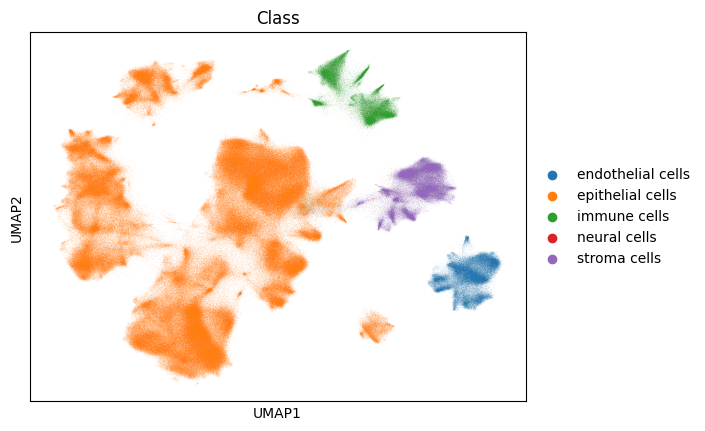

In [18]:
sc.pl.umap(adata, color="Class")


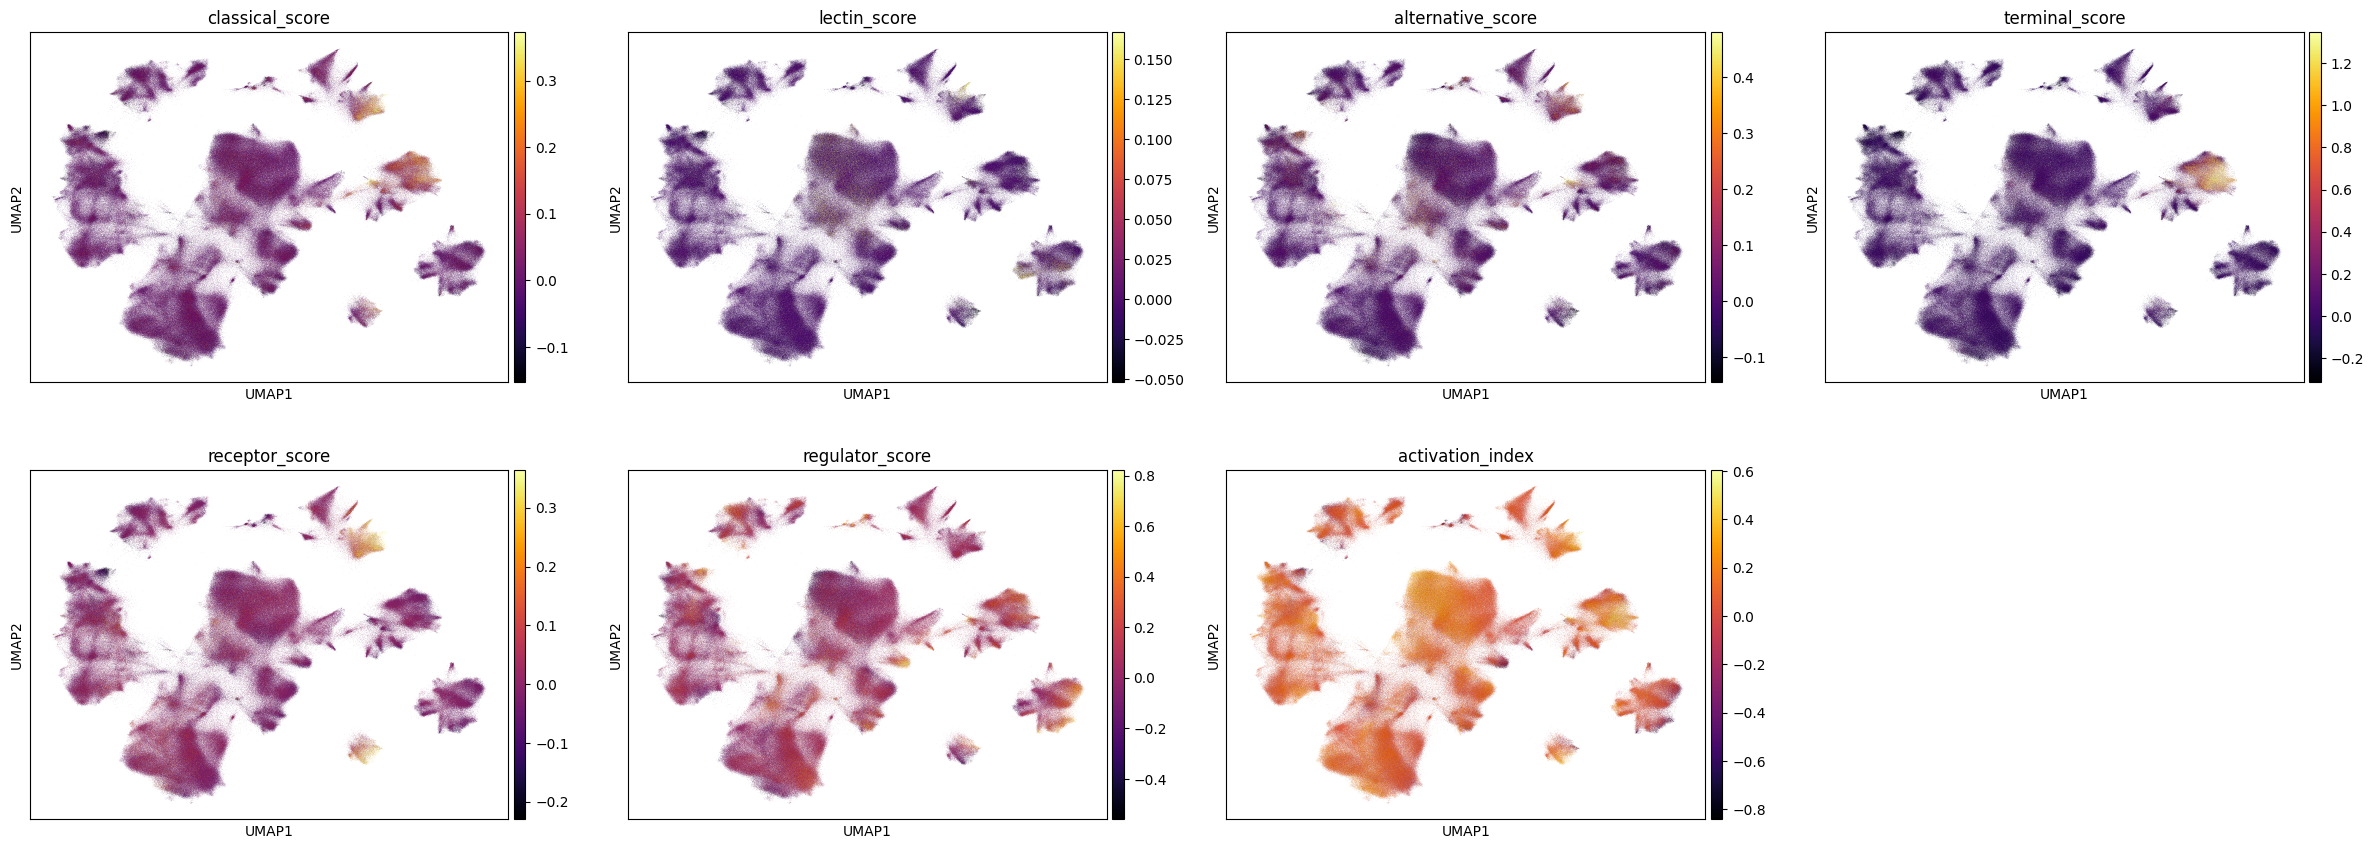

In [19]:
sc.pl.umap(
    adata,
    color=program_score_cols + ["activation_index"],
    cmap="inferno",
    vmin="p1",
    vmax="p99",
)


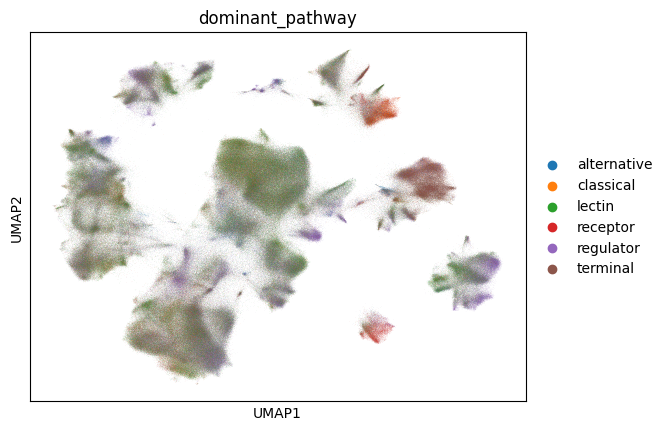

In [20]:
sc.pl.umap(
    adata,
    color="dominant_pathway",
)


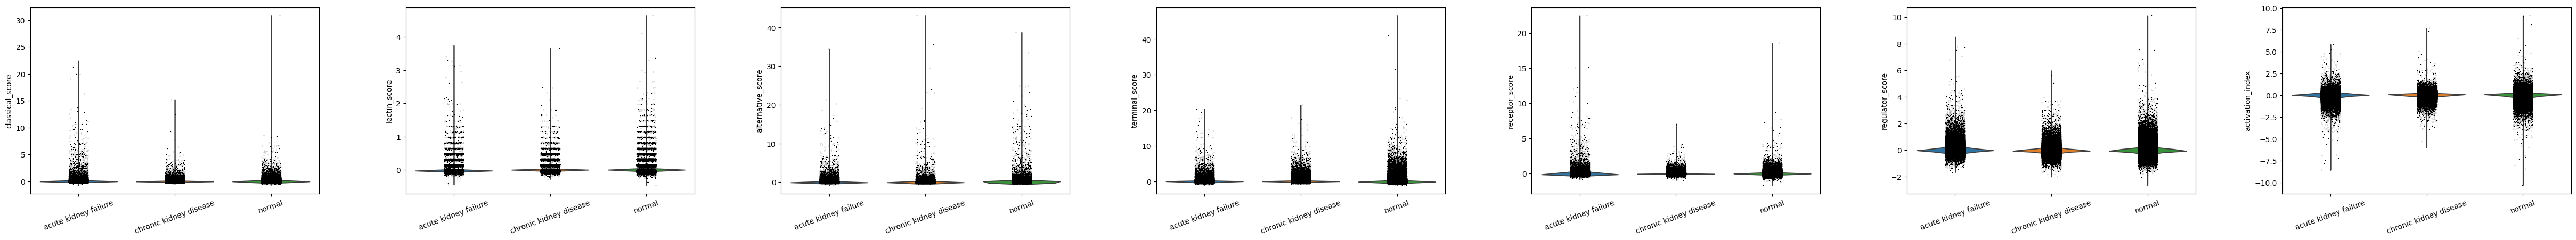

In [21]:
sc.pl.violin(
    adata,
    keys=program_score_cols + ["activation_index"],
    groupby="disease",
    rotation=20,
)
